In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'])
df.set_index('valid_time', inplace=True)

# Define test set
test_df = df.loc['2024-07-01':]
X_test = test_df.drop(columns=['t2m'])
y_test = test_df['t2m']





ARIMA - MAE: 0.6575, RMSE: 0.7949
ETS - MAE: 0.9387, RMSE: 1.1097
Prophet - MAE: 0.9224, RMSE: 1.0112


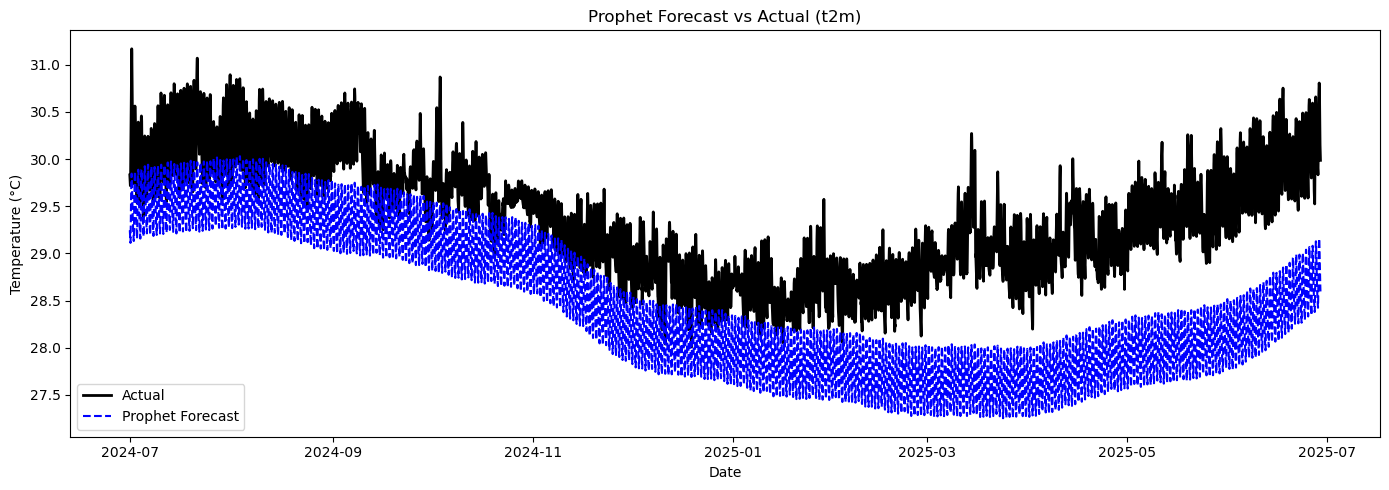

 XGBoost Evaluation:
MAE: 0.0265
RMSE: 0.0400


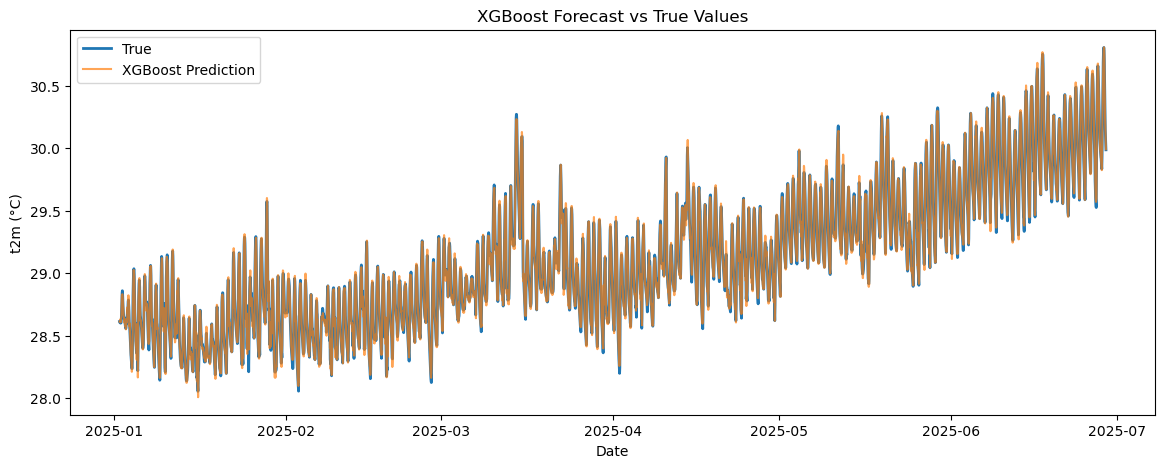

272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
GRU MAE: 0.0257
GRU RMSE: 0.0384


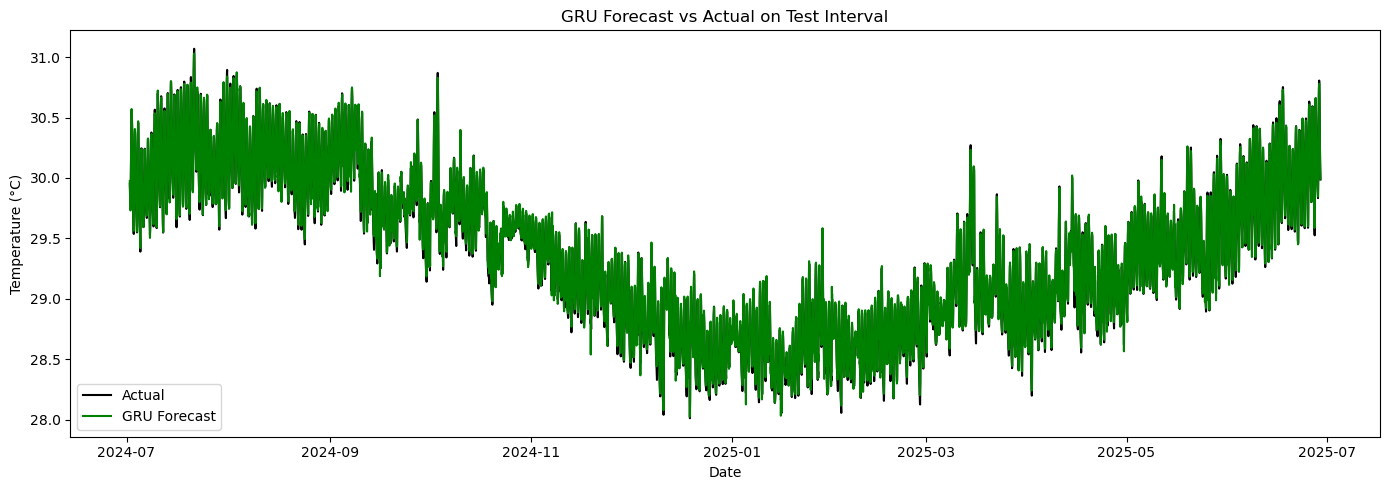

In [26]:
 
# 1️⃣ ARIMA Evaluation
# ========================
from statsmodels.tsa.arima.model import ARIMAResults

arima_model = ARIMAResults.load("../models/statistical/arima_model.pkl")
arima_forecast = arima_model.forecast(steps=len(y_test))

mae_arima = mean_absolute_error(y_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))

print(f"ARIMA - MAE: {mae_arima:.4f}, RMSE: {rmse_arima:.4f}")

# ========================
# 2️⃣ ETS Evaluation
# ========================
import pickle

with open("../models/statistical/ets_model.pkl", "rb") as f:
    ets_model = pickle.load(f)

ets_forecast = ets_model.forecast(steps=len(y_test))

mae_ets = mean_absolute_error(y_test, ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(y_test, ets_forecast))

print(f"ETS - MAE: {mae_ets:.4f}, RMSE: {rmse_ets:.4f}")

# ========================
# 3️⃣ Prophet Evaluation
# ========================
import pickle
from prophet import Prophet

with open("../models/statistical/prophet_model.pkl", "rb") as f:
    prophet_model = pickle.load(f)

future = pd.DataFrame({'ds': y_test.index})
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast['yhat'].values

mae_prophet = mean_absolute_error(y_test, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(y_test, prophet_pred))

print(f"Prophet - MAE: {mae_prophet:.4f}, RMSE: {rmse_prophet:.4f}")

plt.figure(figsize=(14, 5))
plt.plot(test_df.index, test_df['t2m'], label='Actual', color='black', linewidth=2)
plt.plot(prophet_forecast['ds'], prophet_forecast['yhat'], label='Prophet Forecast', color='blue', linestyle='--')

plt.title("Prophet Forecast vs Actual (t2m)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()


# ======================================
# XGBoost Evaluation in 06_test_evaluation.ipynb
# ======================================

import pandas as pd
import pickle
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error


df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'], index_col='valid_time')


test_df = df.loc['2025-01-01':'2025-06-30'].copy()

import sys
import os
sys.path.append(os.path.abspath("../src"))
from feature_engineering import prepare_features
test_features = prepare_features(test_df, lags=list(range(1, 25)))



with open("../models/ml/xgb_feature_list.json", "r") as f:
    feature_list = json.load(f)


X_test = test_features[feature_list]
y_test = test_features['t2m']


with open("../models/ml/xgb_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)


xgb_pred = xgb_model.predict(X_test)


mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f" XGBoost Evaluation:")
print(f"MAE: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test, label="True", linewidth=2)
plt.plot(y_test.index, xgb_pred, label="XGBoost Prediction", alpha=0.7)
plt.title("XGBoost Forecast vs True Values")
plt.xlabel("Date")
plt.ylabel("t2m (°C)")
plt.legend()
plt.show()



# ========================
# 5️⃣ GRU Evaluation
# ========================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow import keras

# Load processed data
df = pd.read_csv("../data/processed/sfax_weather_features.csv", parse_dates=['valid_time'], index_col='valid_time')

# Split test interval
test_df = df.loc['2024-07-01':'2025-06-30'][['t2m']]  # adjust as needed

# Scale using training scaler
scaler = MinMaxScaler()
train_df = df.loc[:'2023-12-31'][['t2m']]
scaler.fit(train_df)

test_scaled = scaler.transform(test_df)

# Create sequences for GRU
def create_sequences(data, timesteps=24):
    X, y = [], []
    for i in range(timesteps, len(data)):
        X.append(data[i-timesteps:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_test, y_test = create_sequences(test_scaled, timesteps=24)

# Load GRU model
from tensorflow import keras
gru_model = keras.models.load_model(
    "../models/dl/gru_model.h5",
    compile=False
)
gru_model.compile(optimizer='adam', loss='mean_squared_error')

# Predict
y_pred_scaled = gru_model.predict(X_test)

#  Inverse scaling
y_pred = scaler.inverse_transform(np.hstack([y_pred_scaled, np.zeros((len(y_pred_scaled), 0))]))[:, 0]
y_true = scaler.inverse_transform(np.hstack([y_test.reshape(-1, 1), np.zeros((len(y_test), 0))]))[:, 0]

# Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"GRU MAE: {mae:.4f}")
print(f"GRU RMSE: {rmse:.4f}")

#  Plot
plt.figure(figsize=(14, 5))
plt.plot(test_df.index[24:], y_true, label='Actual', color='black')
plt.plot(test_df.index[24:], y_pred, label='GRU Forecast', color='green')
plt.title("GRU Forecast vs Actual on Test Interval")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

